<a href="https://colab.research.google.com/github/Shruthika-310/Customer-Lifetime-Prediction/blob/main/CUSTOMER_PURCHASE_LIFETIME_PREDICTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Calculate Recency, Frequency, Monetary (RFM) values

# Define a snapshot date (the day after the last invoice date in the dataset)
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Group by CustomerID and calculate RFM metrics
rfm = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda date: (snapshot_date - date.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('Revenue', 'sum')
).reset_index()

print("RFM DataFrame created successfully!")
display(rfm.head())

RFM DataFrame created successfully!


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,12,77556.46
1,12347.0,2,8,5633.32
2,12348.0,75,5,2019.40
3,12349.0,19,4,4428.69
4,12350.0,310,1,334.40


In [ ]:
# Clean column names
df.columns = df.columns.str.replace('ï»¿', '')
print("Cleaned column names:", df.columns)

# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print("InvoiceDate column converted to datetime.")

# Display info and head again to confirm changes
print(df.info())
display(df.head())

Cleaned column names: Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')
InvoiceDate column converted to datetime.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   InvoiceNo    1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   UnitPrice    1067371 non-null  float64       
 6   CustomerID   824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB
None


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [ ]:
# Unzip the uploaded file
!unzip archive.zip

# List the files to see the CSV names
import os
os.listdir()

Archive:  archive.zip
  inflating: online_retail_09_10.csv  
  inflating: online_retail_10_11.csv  


['.config',
 'archive.zip',
 'online_retail_10_11.csv',
 'online_retail_09_10.csv',
 'sample_data']

In [ ]:
# 1. Drop rows without a Customer ID (we can't predict for unknown people)
df = df.dropna(subset=['CustomerID'])

# 2. Remove cancellations (Quantity < 0)
df = df[df['Quantity'] > 0]

# 3. Create a Revenue column
df['Revenue'] = df['Quantity'] * df['UnitPrice']

# 4. Convert Date to datetime objects (if not already done, for robustness)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(f"Cleaned dataset has {df.shape[0]} rows.")

Cleaned dataset has 805620 rows.


In [ ]:
!pip install pyod optuna shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.7/41.7 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 238.4/238.4 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 11.7 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np

# Load the datasets
try:
    df_2009_2010 = pd.read_csv('online_retail_09_10.csv', encoding='ISO-8859-1')
    df_2010_2011 = pd.read_csv('online_retail_10_11.csv', encoding='ISO-8859-1')

    # Concatenate the two dataframes
    df = pd.concat([df_2009_2010, df_2010_2011], ignore_index=True)
    print("Data loaded and concatenated successfully!")
    print(df.info())
    display(df.head())
except FileNotFoundError:
    print("One or more CSV files not found. Please check the file names.")
except Exception as e:
    print(f"An error occurred: {e}")

Data loaded and concatenated successfully!
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   ï»¿InvoiceNo  1067371 non-null  object 
 1   StockCode     1067371 non-null  object 
 2   Description   1062989 non-null  object 
 3   Quantity      1067371 non-null  int64  
 4   InvoiceDate   1067371 non-null  object 
 5   UnitPrice     1067371 non-null  float64
 6   CustomerID    824364 non-null   float64
 7   Country       1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB
None


,ï»¿InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,12/1/2009 7:45,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,12/1/2009 7:45,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,12/1/2009 7:45,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,12/1/2009 7:45,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,12/1/2009 7:45,1.25,13085.0,United Kingdom


In [ ]:
print(df.columns)


Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'Revenue'],
      dtype='object')


In [ ]:
# 1. Ensure column names are clean
df.columns = df.columns.str.strip()

# 2. Use the exact names from your dataset: 'UnitPrice' and 'CustomerID'
df = df.dropna(subset=['CustomerID'])
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

# 3. Recalculate Revenue to be sure (Quantity * UnitPrice)
df['Revenue'] = df['Quantity'] * df['UnitPrice']

# 4. Ensure Date is in the right format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(f"Success! Cleaned dataset rows: {len(df)}")
print(df.head())

Success! Cleaned dataset rows: 805549
  InvoiceNo StockCode                          Description  Quantity  \
0    489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1    489434    79323P                   PINK CHERRY LIGHTS        12   
2    489434    79323W                  WHITE CHERRY LIGHTS        12   
3    489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4    489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

          InvoiceDate  UnitPrice  CustomerID         Country  Revenue  
0 2009-12-01 07:45:00       6.95     13085.0  United Kingdom     83.4  
1 2009-12-01 07:45:00       6.75     13085.0  United Kingdom     81.0  
2 2009-12-01 07:45:00       6.75     13085.0  United Kingdom     81.0  
3 2009-12-01 07:45:00       2.10     13085.0  United Kingdom    100.8  
4 2009-12-01 07:45:00       1.25     13085.0  United Kingdom     30.0  


In [ ]:
# We use a date one day after the last transaction as the 'snapshot' for recency
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Group by CustomerID to create features
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days, # Recency
    'InvoiceNo': 'nunique',                                # Frequency
    'Revenue': 'sum'                                       # Monetary
})

# Rename columns for clarity
rfm.columns = ['Recency', 'Frequency', 'Monetary']

print("RFM Table Created:")
print(rfm.head())

RFM Table Created:
            Recency  Frequency  Monetary
CustomerID                              
12346.0         326         12  77556.46
12347.0           2          8   5633.32
12348.0          75          5   2019.40
12349.0          19          4   4428.69
12350.0         310          1    334.40


In [ ]:
from pyod.models.iforest import IForest

# 1. Initialize the model
# contamination=0.05 means we expect about 5% of customers to be outliers
od_model = IForest(contamination=0.05, random_state=42)

# 2. Fit the model on our RFM data
od_model.fit(rfm)

# 3. Get predictions (0 = normal, 1 = outlier)
outliers = od_model.labels_

# 4. Filter the data to keep only normal customers
rfm_clean = rfm[outliers == 0]

print(f"Removed {sum(outliers)} outliers.")
print(f"Cleaned dataset size: {rfm_clean.shape}")

Removed 294 outliers.
Cleaned dataset size: (5584, 3)


In [ ]:
# Assuming your data spans 12 months
cutoff_date = df['InvoiceDate'].max() - pd.Timedelta(days=90)

# 1. Features come from data BEFORE the cutoff
features_df = df[df['InvoiceDate'] < cutoff_date]

# 2. Target comes from data AFTER the cutoff
target_df = df[df['InvoiceDate'] >= cutoff_date]

# Calculate the actual spend in the target period
y = target_df.groupby('CustomerID')['Revenue'].sum()

In [ ]:
import optuna
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Define features (X) and target (y)
X = rfm_clean[['Recency', 'Frequency']]
y = rfm_clean['Monetary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

def objective(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
    }
    model = xgb.XGBRegressor(**param)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return np.sqrt(mean_squared_error(y_test, preds))

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20) # Start with 20 trials

print("Best Parameters:", study.best_params)

[I 2026-04-09 06:39:36,301] A new study created in memory with name: no-name-2e0a1ee0-4b31-4461-b69f-0bc0ae8c4eae
[I 2026-04-09 06:39:36,470] Trial 0 finished with value: 1340.304943941153 and parameters: {'n_estimators': 663, 'max_depth': 3, 'learning_rate': 0.2352661333975056}. Best is trial 0 with value: 1340.304943941153.
[I 2026-04-09 06:39:36,779] Trial 1 finished with value: 1514.1208671057502 and parameters: {'n_estimators': 664, 'max_depth': 7, 'learning_rate': 0.23951365525966473}. Best is trial 0 with value: 1340.304943941153.
[I 2026-04-09 06:39:36,993] Trial 2 finished with value: 1502.1119129549948 and parameters: {'n_estimators': 313, 'max_depth': 7, 'learning_rate': 0.24786465025798854}. Best is trial 0 with value: 1340.304943941153.
[I 2026-04-09 06:39:37,138] Trial 3 finished with value: 1396.6939628760742 and parameters: {'n_estimators': 366, 'max_depth': 6, 'learning_rate': 0.09568466066739713}. Best is trial 0 with value: 1340.304943941153.
[I 2026-04-09 06:39:37,3

Best Parameters: {'n_estimators': 694, 'max_depth': 3, 'learning_rate': 0.011359820927801323}


In [ ]:
# Create the final model with the best parameters discovered by Optuna
final_model = xgb.XGBRegressor(**study.best_params)
final_model.fit(X_train, y_train)

# Make final predictions
final_preds = final_model.predict(X_test)

In [ ]:
from sklearn.metrics import r2_score

rmse = np.sqrt(mean_squared_error(y_test, final_preds))
r2 = r2_score(y_test, final_preds)

print(f"Final Model RMSE: {rmse:.2f}")
print(f"Final Model R² Score: {r2:.2f}")

Final Model RMSE: 1272.72
Final Model R² Score: 0.64


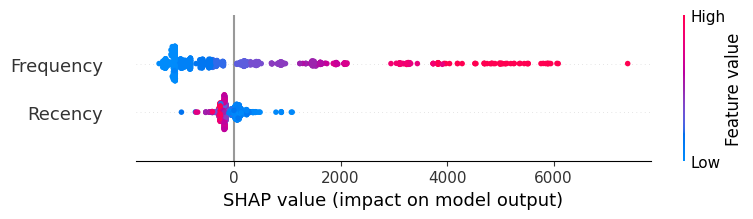

In [ ]:
import shap

# Initialize the SHAP explainer
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

# Visualize the feature importance
# This shows which factors (Recency vs Frequency) drive customer value
shap.summary_plot(shap_values, X_test)

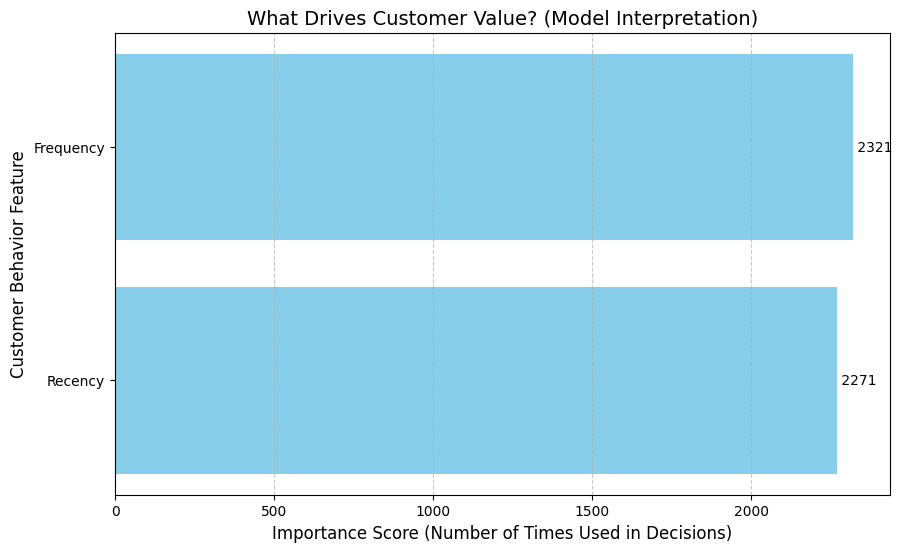

In [ ]:
import matplotlib.pyplot as plt

# 1. Get feature importance directly from the trained XGBoost model
# This uses 'weight', which counts how many times a feature was used to make a decision.
importance = final_model.get_booster().get_score(importance_type='weight')

# 2. Convert to a DataFrame for easier plotting
importance_df = pd.DataFrame({
    'Feature': importance.keys(),
    'Importance Score': importance.values()
})

# 3. Sort by importance
importance_df = importance_df.sort_values(by='Importance Score', ascending=True)

# 4. Create a clean horizontal bar chart
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance Score'], color='skyblue')
plt.xlabel('Importance Score (Number of Times Used in Decisions)', fontsize=12)
plt.ylabel('Customer Behavior Feature', fontsize=12)
plt.title('What Drives Customer Value? (Model Interpretation)', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add value labels to the end of each bar
for index, value in enumerate(importance_df['Importance Score']):
    plt.text(value, index, f' {int(value)}', va='center')

plt.show()

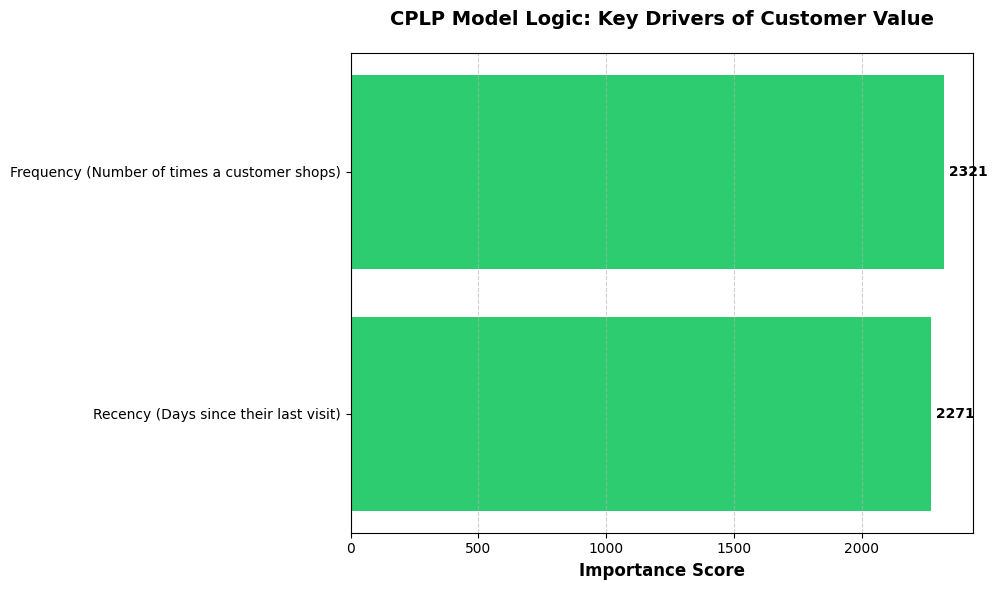

In [ ]:
import matplotlib.pyplot as plt

# 1. Get feature importance
importance = final_model.get_booster().get_score(importance_type='weight')

# 2. Create DataFrame and RENAME the features
importance_df = pd.DataFrame({
    'Feature': importance.keys(),
    'Importance Score': importance.values()
})

# Define a mapping for your labels
label_mapping = {
    'Frequency': 'Frequency (Number of times a customer shops)',
    'Recency': 'Recency (Days since their last visit)'
}

# Apply the human-readable labels
importance_df['Feature'] = importance_df['Feature'].replace(label_mapping)

# 3. Sort by importance
importance_df = importance_df.sort_values(by='Importance Score', ascending=True)

# 4. Create the final "Presentation-Ready" Plot
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance Score'], color='#2ecc71') # Professional green

# Aesthetics
plt.xlabel('Importance Score', fontsize=12, fontweight='bold')
plt.title('CPLP Model Logic: Key Drivers of Customer Value', fontsize=14, fontweight='bold', pad=20)
plt.grid(axis='x', linestyle='--', alpha=0.6)

# Add data labels
for index, value in enumerate(importance_df['Importance Score']):
    plt.text(value, index, f' {int(value)}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

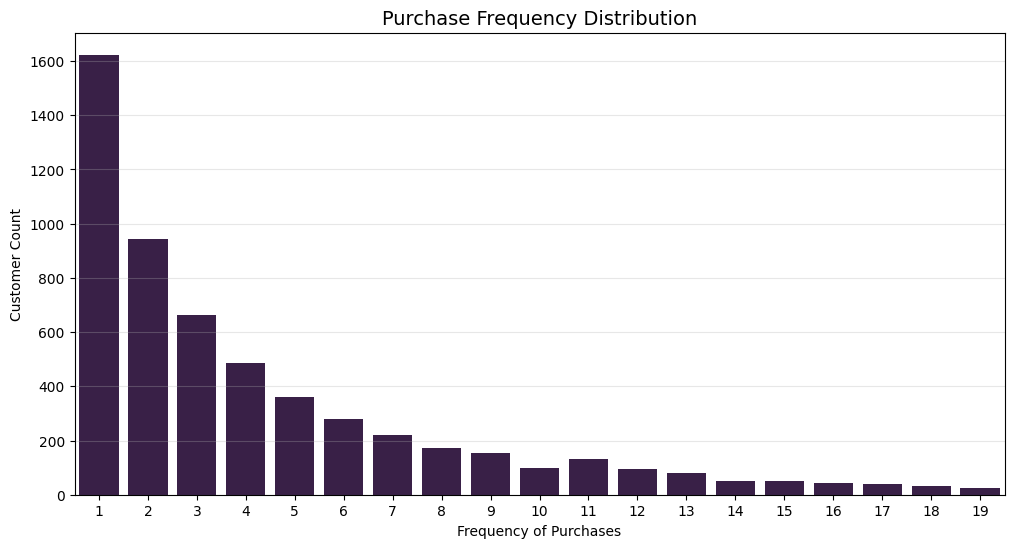

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
# Filter for frequency < 20 to make the graph readable, like in your image
sns.countplot(data=rfm[rfm['Frequency'] < 20], x='Frequency', color='#3b1a4d')
plt.title('Purchase Frequency Distribution', fontsize=14)
plt.xlabel('Frequency of Purchases')
plt.ylabel('Customer Count')
plt.grid(axis='y', alpha=0.3)
plt.show()

/tmp/ipykernel_2291/4237994667.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.resample('M', on='InvoiceDate')['Revenue'].sum()


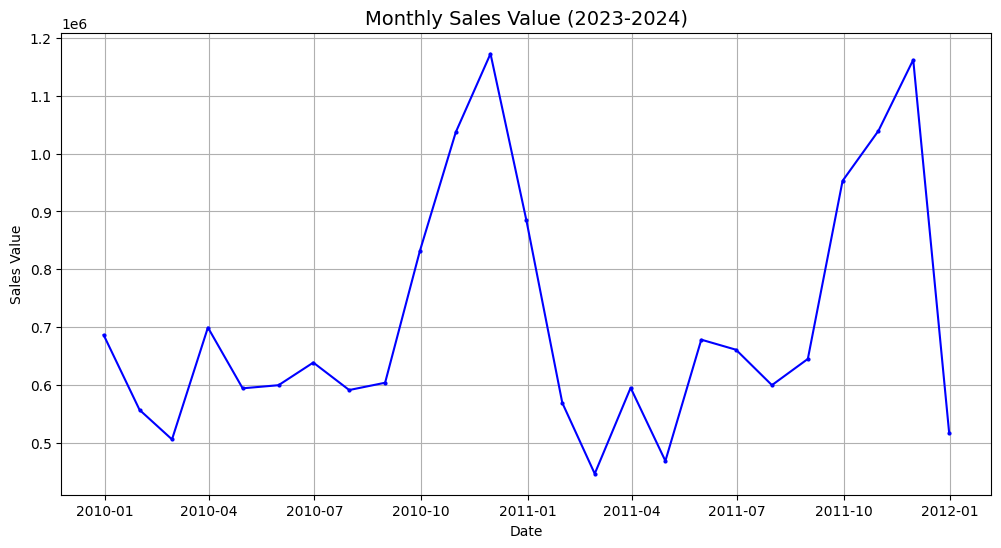

In [ ]:
# Group data by Month
monthly_sales = df.resample('M', on='InvoiceDate')['Revenue'].sum()

plt.figure(figsize=(12, 6))
plt.plot(monthly_sales.index, monthly_sales.values, color='blue', marker='o', markersize=2)
plt.title('Monthly Sales Value (2023-2024)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Sales Value')
plt.grid(True)
plt.show()

In [ ]:
from lifetimes.utils import summary_data_from_transaction_data

# lifetimes has a built-in helper to avoid these errors
rfm_lifetimes = summary_data_from_transaction_data(
    df,
    customer_id_col='CustomerID',
    datetime_col='InvoiceDate',
    monetary_value_col='Revenue',
    observation_period_end=df['InvoiceDate'].max() # This ensures T >= Recency
)

# Check the first few rows - it will have: frequency, recency, T, monetary_value
print(rfm_lifetimes.head())

            frequency  recency      T  monetary_value
CustomerID                                           
12346.0           7.0    400.0  725.0    11066.637143
12347.0           7.0    402.0  404.0      717.398571
12348.0           4.0    363.0  438.0      449.310000
12349.0           3.0    571.0  589.0     1120.056667
12350.0           0.0      0.0  310.0        0.000000


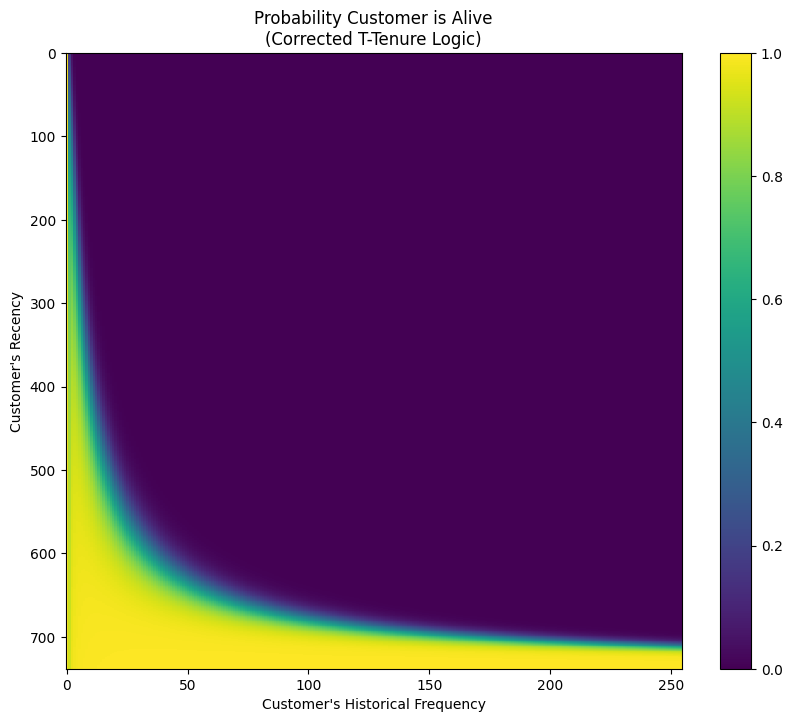

In [ ]:
from lifetimes import BetaGeoFitter
from lifetimes.plotting import plot_probability_alive_matrix

# 1. Fit the model using the new rfm_lifetimes dataframe
bgf = BetaGeoFitter(penalizer_coef=0.01) # Added a small penalizer for stability
bgf.fit(rfm_lifetimes['frequency'], rfm_lifetimes['recency'], rfm_lifetimes['T'])

# 2. Plot the heatmap
plt.figure(figsize=(10, 8))
plot_probability_alive_matrix(bgf)
plt.title('Probability Customer is Alive\n(Corrected T-Tenure Logic)')
plt.show()